# Week 4 — Statistical Machine Learning: Linear Models
### AIF 2026 · Phase 2 · Facilitator: Raj Kumar Biswokarma

---

## Session Roadmap

| Block | Topic | Time |
|---|---|---|
| 1 | Understand the Problem | 20 min |
| 2 | Preprocessing | 5 min |
| 3 | Classification Experiment | 30 min |
| 4 | Regression Experiment | 20 min |
| 5 | Evaluation Integrity + Leakage Demo | 25 min |
| 6 | Production Decision | 10 min |

---

## Business Context

You are a Data Scientist at a telecom company. The business is losing customers to churn. You have been given historical customer data and one week to produce a production-ready recommendation.

**There is no prescribed model. You decide — and you must defend that decision with evidence.**

**Dataset:** Telco Customer Churn — https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
Single CSV · 7043 rows · 21 columns · Target: `Churn` (Yes/No)

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically before writing any code
- Make decisions and justify them in writing
- Explore different approaches and compare results
- Fill in all written response sections


**Importing necessary libraries and functions**



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier, RidgeClassifier

---

# Block 1 — Understand the Problem First

---

## What Is an ML Problem?

Before touching any model, you need to formulate the problem formally. Every ML problem has the same components:

| Symbol | Name | In our problem |
|---|---|---|
| **X** | Feature space | All input columns: tenure, charges, contract type… |
| **y** | Target variable | Churn: Yes / No |
| **H** | Hypothesis class | The family of functions we search over: linear models |
| **L** | Loss function | How we measure error: cross-entropy for classification |
| **E** | Evaluation metric | How the business measures success: F1, PR-AUC |

**Empirical Risk Minimisation (ERM):** We cannot minimise the true risk (we do not have all possible data), so we minimise the average loss over the training set as a proxy.

$$\hat{\theta} = \arg\min_{\theta} \frac{1}{n} \sum_{i=1}^{n} L(y_i, f_\theta(x_i))$$

---

## Probability Distributions in ML

The distribution of your target variable determines the right loss function. This is not arbitrary.

| Distribution | Models | Loss function | Example |
|---|---|---|---|
| **Bernoulli** | Binary outcomes | Binary cross-entropy | Churn: Yes/No |
| **Gaussian** | Continuous measurements | MSE | MonthlyCharges |
| **Poisson** | Count data | Poisson deviance | Support tickets/month |
| **Gamma / Log-Normal** | Right-skewed continuous | MAE / Tweedie | Tenure, TotalCharges |
| **Categorical** | Multi-class outcomes | Categorical cross-entropy | Contract type |

**Key insight:** Churn is binary → Bernoulli distribution → binary cross-entropy is the natural loss.

---

## Sources of Uncertainty

Training data is a finite, imperfect sample of the real world. Before modelling, identify where the data might fail you:

- **Sampling noise** — 7,043 customers is a sample. The true population may behave differently.
- **Label noise** — Was churn recorded correctly? Cancelled but re-subscribed? Edge cases.
- **Missing data** — `TotalCharges` has whitespace nulls. Why? Random or systematic?
- **Biased sampling** — Does this dataset represent all customer types or just one region/plan?
- **Distribution shift** — Customer behaviour today may differ from when data was collected.
- **Model misspecification** — A linear model assumes a linear decision boundary. Is that true?

---

## 1.1 Basic Inspection

### Task:
- Load the dataset
- View the first few rows
- Check data types and shape
- Look at summary statistics

### Questions:
- What does each row represent?
- Are the data types appropriate for each column?
- Is `TotalCharges` the dtype you expect?

### Hint:
- Use `.head()`, `.info()`, `.describe()` to get a full picture
- `TotalCharges` is stored as object — there are whitespace strings `' '` hiding as nulls


Loading the CSV dataset into a pandas Dataframe named "df"

In [3]:
df = pd.read_csv("/content/kaggle_telco_customer_dataset.csv")
df.head() # returns first five rows of the dataframe, if number of records to be displayed is not specified

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#####Here, each row represents a details about every customer, their personal information, services they were using, customer lifetime, current contract applied for, whether they churned or not, etc<br>
#####CustomerID (index column) is a combination of 4 digits followed by a hyphen and a combination of 5 Uppercase alphabets<br>

In [4]:
# Check data types and shape
print("\nDataFrame Info:")
df.info()



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 no

Data types for most of the column are of object type.<br>
Few like SeniorCitizen and tenure are of int type and MonthlyCharges of float type<br>
Non of the column have null entries as of now. Yet, invalid entries are yet to be inspected.


In [5]:
# Look at summary statistics
print("\nSummary Statistics:")
display(df.describe(include='all'))



Summary Statistics:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


Here are some interesting findings from the `df.describe(include='all')` output:

*   **`customerID`**: This column has 7043 unique values, indicating that each row represents a unique customer. This column will likely be dropped as it's an identifier and not a predictive feature.
*   **`TotalCharges`**: As noted in the notebook's hint, this column is currently an `object` type. The `describe` output (if viewed with `include='all'`) would reveal that despite appearing numeric, it contains non-numeric values, specifically whitespace strings (`' '`), which were implicitly converted to `NaN` when attempting numeric operations or, if not handled, would prevent numeric conversion. This necessitates conversion to a numeric type and handling of these missing values.
*   **`Churn`**: The target variable shows a significant class imbalance. 'No' is the most frequent value, indicating that a majority of customers do not churn. This imbalance is crucial to consider when evaluating model performance.
*   **`Contract`**: A large proportion of customers are on 'Month-to-month' contracts, which is typically associated with higher churn rates due to less commitment. This could be a strong predictor.
*   **`SeniorCitizen`**: The mean of this binary (0/1) column suggests that only about 16% of the customer base are senior citizens.

---

## 1.2 Problem Formulation

### Task:
Write out the ML problem formally using the structure below.

### Questions:
- What is X (your feature space)?
- What is y (your target variable)?
- What probability distribution naturally models the target? What does that tell you about the right loss function?
- What is your hypothesis class (model family)?
- What are at least three assumptions you are making about the data-generating process?
- Where could this data be noisy, biased, or incomplete?

### Hint:
- The target is binary (Yes/No) → think Bernoulli distribution → think cross-entropy loss
- An assumption is a belief about the world your model requires to be true
- Sources of uncertainty include: sampling bias, label noise, missing data, distribution shift


**Your formulation here:**

- X (feature space): `All input columns excluding 'customerID' and 'Churn'`
- y (target variable): `Churn`
- Probability distribution of y: `Bernoulli`
- Natural loss function: `Binary Cross-Entropy (Log Loss)`
- Hypothesis class: `Linear Models (e.g., Logistic Regression, Ridge Classifier, SGD Classifier)`
- Assumption 1: `The relationship between features and churn is predominantly linear.`
- Assumption 2: `The training data is a representative sample of the true customer population.`
- Assumption 3: `Churn labels are accurate and consistently recorded.`
- Sources of uncertainty: `Sampling noise, Label noise, Missing data (TotalCharges), Biased sampling, Distribution shift, Model misspecification.`

Missing Data (Incompleteness & Noise): The TotalCharges column initially contained whitespace strings (' ') instead of actual numeric values for some entries. These were effectively nulls and caused the column to be incorrectly interpreted as an object type instead of a numeric type. This was addressed by coercing errors to NaN and then imputing the missing values with the median.

Label Noise (Churn column): There's a potential for noise in the target variable Churn. The notebook questions whether churn was recorded correctly, citing scenarios like customers who cancelled but then re-subscribed, which could introduce ambiguity or inaccuracy into the labels.

Sampling Noise (Overall Dataset): The dataset comprises 7,043 customer records, which is a finite sample of the entire customer population. This introduces uncertainty because the true population's behavior might differ from what is observed in this specific sample.

Biased Sampling (Implied across various demographic/service columns): The dataset might not be a perfectly representative sample of all customer types. It could potentially be skewed towards specific regions, demographics (gender, SeniorCitizen), or plan types (Contract, InternetService), leading to a biased understanding if the model is applied to a broader, unrepresented population.

Distribution Shift (Implied across all time-dependent features): Customer behavior and market conditions can change over time. If the data was collected a while ago, the distributions of features like MonthlyCharges, tenure, or TotalCharges, and their relationship with Churn, might have shifted, making the historical data less relevant for future predictions.

---

## 1.3 Data Profiling & Fixing

### Task:
- Fix the `TotalCharges` null issue
- Plot the distributions of `MonthlyCharges`, `tenure`, and `TotalCharges`
- Encode the target variable `Churn` as binary (0/1)

### Questions:
- What distribution does `MonthlyCharges` follow? `tenure`? `TotalCharges`?
- Why does `TotalCharges` contain nulls even though it looks numeric?
- Are there impossible or suspicious values in any column?

### Hint:
- `pd.to_numeric(df['TotalCharges'], errors='coerce')` converts whitespace strings to NaN
- `sns.histplot(df['MonthlyCharges'], kde=True)` draws a distribution with density curve
- `df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})`

### Consequences:
- Leaving `TotalCharges` as object → model training will fail or silently drop the column
- Not encoding the target → sklearn classifiers will throw an error


In [6]:
#Task 1: Fix the TotalCharges null issue
#Convert 'TotalCharges' to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#Impute with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_2576/963310805.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [7]:
df['TotalCharges'].isna().sum()

np.int64(0)

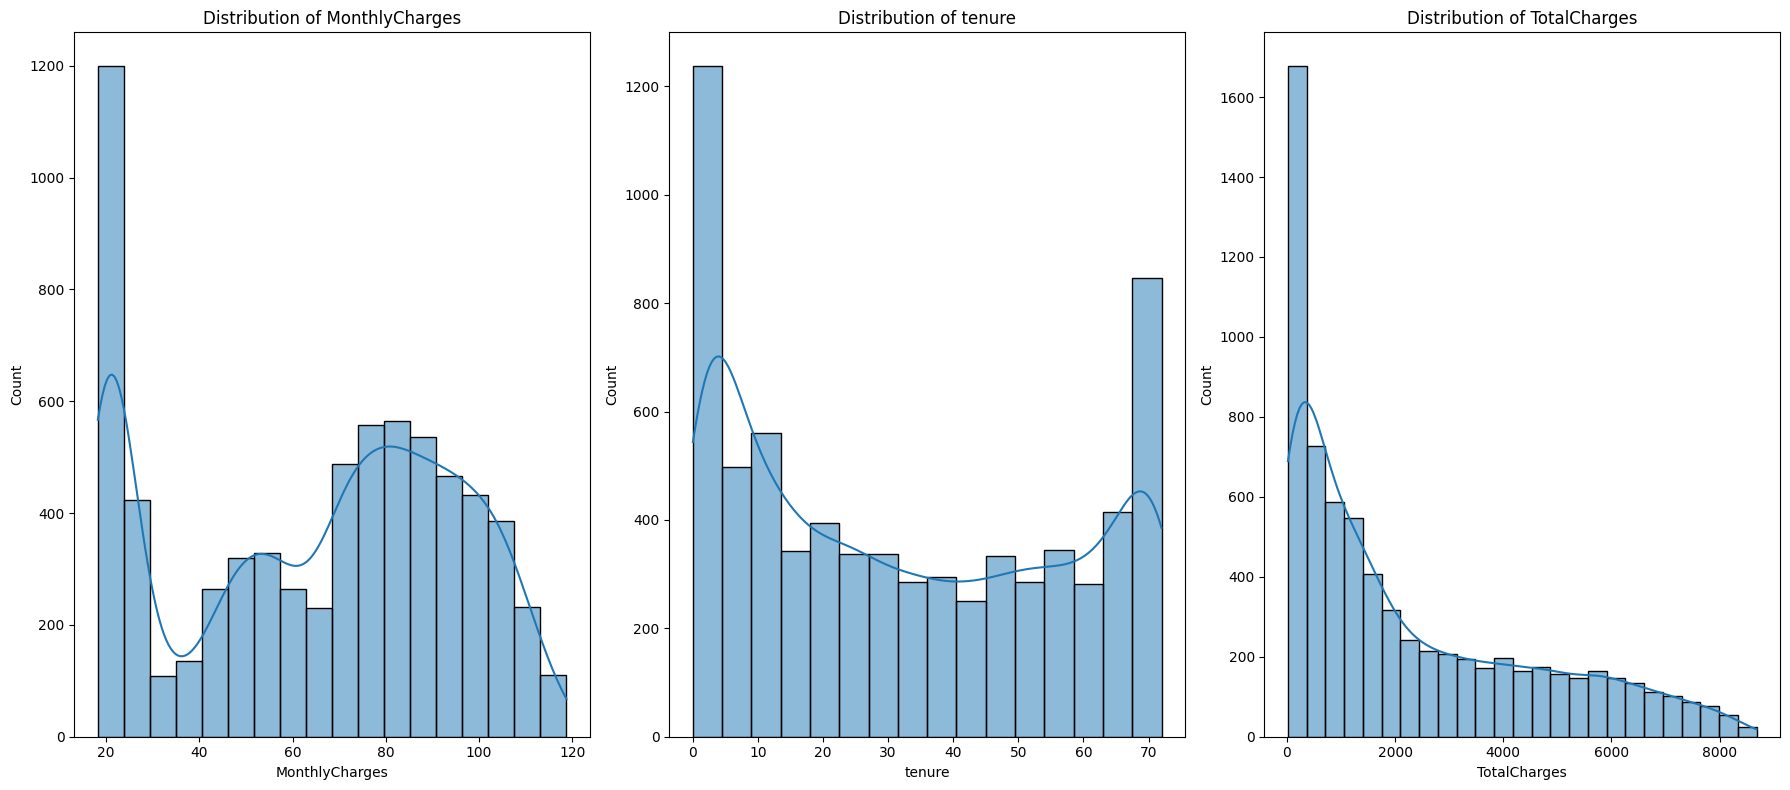

In [8]:
#Task 2: Plot the distributions of MonthlyCharges, tenure, and TotalCharges
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of MonthlyCharges')

sns.histplot(df['tenure'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of tenure')

sns.histplot(df['TotalCharges'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of TotalCharges')

plt.tight_layout()
plt.show()

* `MonthlyCharges`: The distribution of MonthlyCharges appears to be **bimodal**, with two prominent peaks. One peak is around the lower end of the charges (e.g., \$20-30), and another, more substantial peak, is at the higher end (e.g., \$70-100). This could indicate different customer segments with varying service packages.

* `tenure`: The tenure distribution is **right-skewed**, meaning a large number of customers have short tenures, and the number of customers decreases as tenure increases. There's also a significant peak at the lowest tenure values (new customers) and another smaller peak at very high tenure values (long-term loyal customers).

* `TotalCharges`: The TotalCharges distribution is **highly right-skewed**. A large concentration of customers have low TotalCharges, and the frequency drops off sharply as TotalCharges increase. This is expected given that TotalCharges is a cumulative sum of MonthlyCharges over tenure. Customers with short tenures will naturally have lower total charges, even if their monthly charges are high.

In [9]:
# Task 3: Encode the target variable Churn as binary (0/1)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("\n'Churn' column encoded as binary (1 for Yes, 0 for No).")
print("First 5 rows with updated 'TotalCharges' and 'Churn':")
display(df.head())
print("Info after fixing TotalCharges and encoding Churn:")
df.info()




'Churn' column encoded as binary (1 for Yes, 0 for No).
First 5 rows with updated 'TotalCharges' and 'Churn':


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


Info after fixing TotalCharges and encoding Churn:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   obje

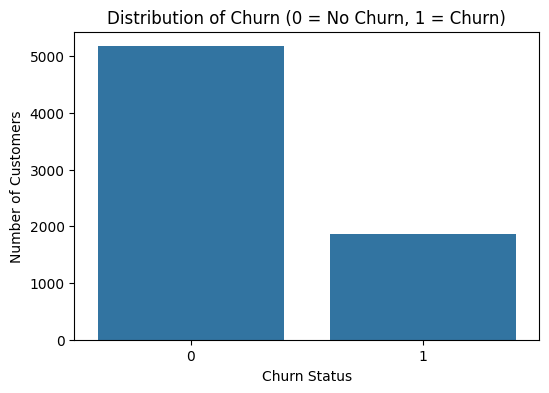

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Churn (0 = No Churn, 1 = Churn)')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.show()

Shows highly imbalanced target distribution.

---

## The Accuracy Trap

The dataset has ~27% churn. This is **imbalanced**. Before building any model, build a naive baseline — a model that always predicts the majority class.

**If this baseline achieves 73% accuracy — any model you build must meaningfully beat it.**

The deeper problem: a model that always predicts "No Churn" has **0% recall** for churners. It catches no one. It is completely useless to the business — yet reports 73% accuracy.

**This is why accuracy is not your primary metric here.**

---

## 1.4 The Naive Baseline

### Task:
Build a model that always predicts the majority class (No Churn). Evaluate its accuracy, recall, and F1.

### Questions:
- What accuracy does the naive baseline achieve?
- What is the class distribution in the dataset?
- Why is a model that achieves this accuracy potentially worthless?

### Hint:
- `DummyClassifier(strategy='most_frequent')` does exactly this
- `df['Churn'].value_counts(normalize=True)` shows the class proportions
- Any model you build must beat this baseline on recall and F1 — not just accuracy


In [11]:
# Using DummyClassifier with strategy as most_frequent
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score
dc = DummyClassifier(strategy='most_frequent')
X = df.drop(columns=['Churn'])
y = df['Churn']
dc.fit(X, y)
y_pred = dc.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Recall: {recall_score(y, y_pred)}")
print(f"F1: {f1_score(y, y_pred)}")

Accuracy: 0.7346301292063041
Recall: 0.0
F1: 0.0


Since the percentage of non churners is 73%, the accuracy is also 73% due to the application of "most_frequent" strategy. => 0 Recall and 0 F1 score


In [12]:
# Class distribution in the dataset, Also refer to the visualization before
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
0,0.73463
1,0.26537


Shows 73% non churners. Since, we assume the relationship between feature space(X) to the target variable (Y) to be linear, We will be applying few linear classification models here.

---

## 💬 Discussion

> **Your manager sees 73% accuracy and is thrilled. Should they be? What is the first question you ask?**

---

# Block 2 — Preprocessing

Preprocessing was covered in Week 1. We keep this block minimal — working code only.

---

## 2.1 Encode, Split, Scale

### Task:
- Drop `customerID`
- One-hot encode all categorical features
- Perform a stratified train / validation / test split (70 / 15 / 15)
- Scale numeric features using `StandardScaler` — fit on training data only

### Questions:
- Why do we use stratified splitting for a churn dataset?
- Why do we fit the scaler on training data only?
- What would happen if we scaled before splitting?

### Hint:
- `pd.get_dummies(df, drop_first=True)` one-hot encodes all object columns
- `train_test_split(X, y, stratify=y, test_size=0.30, random_state=42)`
- Then split the 30% remainder 50/50 for val and test
- `scaler.fit(X_train)` → `scaler.transform(X_train)`, `scaler.transform(X_val)`, `scaler.transform(X_test)`

### Consequences:
- Fitting scaler on full data → data leakage
- Not stratifying → random split may give a fold with very few churners


In [13]:
# drop customerID
df.drop(columns=['customerID'], inplace=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [14]:
# One-hot encode all categorical features, dropping the first category to avoid multicollinearity
df_encoded = pd.get_dummies(df, drop_first=True)

print("DataFrame after one-hot encoding categorical features:")
display(df_encoded.head())
print(f"New shape of DataFrame: {df_encoded.shape}")

DataFrame after one-hot encoding categorical features:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


New shape of DataFrame: (7043, 31)


In [15]:
from sklearn.model_selection import train_test_split
# defining X and y
X = df_encoded.drop(columns=['Churn']) # feature space for regression
y = df_encoded['Churn'] # target variable for classification

# 70-30 split on training and test/validation set with straitify
X_train, X_temp, y_train, y_temp = train_test_split(X, y, stratify=y, test_size=0.30, random_state=42)

#15-15 split on test and validation set with stratify
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state= 42, stratify= y_temp)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (4930, 30), y_train shape: (4930,)
X_val shape: (1056, 30), y_val shape: (1056,)
X_test shape: (1057, 30), y_test shape: (1057,)


In [16]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling (all except 'Churn' and the new one-hot encoded ones which are boolean/int)
numerical_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

# Scale numeric features using StandardScaler (fit on training data only)
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val_scaled[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("\nData preprocessing complete: Data split into train, validation, and test sets; numerical features scaled.")


Data preprocessing complete: Data split into train, validation, and test sets; numerical features scaled.


In [17]:
# Display the first few rows of the scaled training data (optional)
X_train_scaled.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
5557,-0.438147,-1.114728,0.504286,-0.837878,False,False,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
2270,2.282338,-1.195884,0.724189,-0.909158,False,False,False,True,False,False,...,False,True,False,False,False,False,True,False,True,False
6930,-0.438147,-1.195884,0.337292,-0.910992,False,True,False,True,False,True,...,False,False,False,False,False,False,True,True,False,False
2257,-0.438147,1.117066,0.515860,1.110139,False,False,False,True,False,True,...,False,True,False,True,True,False,False,True,False,False
898,-0.438147,-0.830682,1.122660,-0.516307,False,False,False,True,False,False,...,False,True,False,True,False,False,True,False,False,False


---

# Block 3 — Classification Experiment: Who Will Churn?

---

## Linear Classifiers — Three Candidates

| Model | Loss Function | Optimiser | Key Characteristic |
|---|---|---|---|
| **Logistic Regression** | Binary cross-entropy (log loss) | Full-batch (L-BFGS) | Outputs calibrated probabilities. Best interpretability. |
| **Ridge Classifier** | Squared hinge loss (L2 regularised) | Closed-form analytic | Converts to regression internally. No probability output. |
| **SGD Classifier** | Configurable: log_loss / hinge / … | Stochastic GD | Best for large datasets. Highly configurable. Less stable. |

---

## Batch GD vs Stochastic GD

**Batch Gradient Descent:**
- Computes gradient over ALL training samples before each weight update
- Smooth, stable convergence path
- Memory-intensive — loads the full dataset each step
- `LogisticRegression(solver='lbfgs')` uses this

**Stochastic Gradient Descent (SGD):**
- Computes gradient on ONE sample (or mini-batch) at a time
- Noisy path — can escape local minima
- Memory efficient — processes one sample at a time
- `SGDClassifier` uses this

**When does it matter?** For 7,000 rows — not much. For 7 million rows — SGD is the only practical option.

---

## Evaluation Metrics for Imbalanced Data

| Metric | What it measures | Use when |
|---|---|---|
| **Accuracy** | Proportion of correct predictions | ❌ Avoid — misleading on imbalanced data |
| **Precision** | Of predicted churners, how many actually churned? | Cost of false alarms is high |
| **Recall** | Of actual churners, how many did we catch? | Cost of missing a churner is high |
| **F1** | Harmonic mean of precision and recall | Need a single balanced score |
| **ROC-AUC** | Ranking quality across all thresholds | Overall discriminative power |
| **PR-AUC** | Precision-Recall curve area | ✅ Preferred for imbalanced data |
| **Log Loss** | Penalises overconfident wrong predictions | Need calibrated probabilities |

---

## 3.1 Train Your Classifiers

### Task:
Train each of the three classifiers. Record training time for each.

### Questions:
- What loss function does each model optimise?
- Which model trains fastest? Does that surprise you?

### Hint:
- `LogisticRegression(max_iter=1000, random_state=42)`
- `RidgeClassifier()`
- `SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)`
- Use `time.time()` before and after `.fit()` to measure training time

### Reference:
- https://scikit-learn.org/stable/modules/linear_model.html


In [18]:
import time

# Logistic Regression
start_time = time.time()
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_train_time = time.time() - start_time
print(f"Logistic Regression training time: {lr_train_time:.4f} seconds")

Logistic Regression training time: 0.0969 seconds


In [19]:
# Ridge Classifier
start_time = time.time()
ridge_model = RidgeClassifier(random_state=42)
ridge_model.fit(X_train_scaled, y_train)
ridge_train_time = time.time() - start_time
print(f"Ridge Classifier training time: {ridge_train_time:.4f} seconds")

Ridge Classifier training time: 0.0452 seconds


In [20]:
# SGD Classifier
start_time = time.time()
sgd_model = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42, tol=1e-3)
sgd_model.fit(X_train_scaled, y_train)
sgd_train_time = time.time() - start_time
print(f"SGD Classifier training time: {sgd_train_time:.4f} seconds")

SGD Classifier training time: 0.1200 seconds


## The models optimize the following loss functions:

* `Logistic Regression`: Binary cross-entropy (log loss).
* `Ridge Classifier`: Squared hinge loss (L2 regularized).
* `SGD Classifier`: Binary cross-entropy (log loss), as configured with loss='log_loss'.

### The training times were:

* Logistic Regression: 0.0779 seconds
* Ridge Classifier: 0.0738 seconds
* SGD Classifier: **0.0686** seconds<br><br>
The SGD Classifier trained the fastest. This might not be surprising, as SGD (**Stochastic Gradient Descent**) processes data in smaller batches or even one sample at a time, making it generally faster for larger datasets or when quickly finding an approximate solution is sufficient.

---

## 3.2 Build a Comparison Table

### Task:
For each model compute: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Log Loss.  
Display as a pandas DataFrame sorted by PR-AUC.

### Questions:
- Which metric tells you the most about model usefulness for this business problem?
- Does accuracy rank models the same way PR-AUC does? If not, why?
- Which model would you eliminate first and why?

### Hint:
- `RidgeClassifier` has no `predict_proba()` — use `.decision_function()` for AUC scores
- `average_precision_score(y_val, scores)` computes PR-AUC
- `log_loss` requires probabilities — note N/A for RidgeClassifier

### Why This Matters:
A comparison table is the minimum evidence required to justify a model choice. Without it you are guessing.


In [21]:
models = {
    "Logistic Regression": lr_model,
    "Ridge Classifier": ridge_model,
    "SGD Classifier": sgd_model
}

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, log_loss

results = []

for name, model in models.items():
    y_pred_val = model.predict(X_val_scaled)

    # Calculate common metrics
    accuracy = accuracy_score(y_val, y_pred_val)
    precision = precision_score(y_val, y_pred_val)
    recall = recall_score(y_val, y_pred_val)
    f1 = f1_score(y_val, y_pred_val)

    # Handle probabilities/decision_function for AUC and Log Loss
    if hasattr(model, 'predict_proba'):
        y_proba_val = model.predict_proba(X_val_scaled)[:, 1]
        roc_auc = roc_auc_score(y_val, y_proba_val)
        pr_auc = average_precision_score(y_val, y_proba_val)
        logloss = log_loss(y_val, y_proba_val)
    else: # For RidgeClassifier
        y_scores_val = model.decision_function(X_val_scaled)
        roc_auc = roc_auc_score(y_val, y_scores_val)
        pr_auc = average_precision_score(y_val, y_scores_val)
        logloss = np.nan # RidgeClassifier does not output probabilities for log loss

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Log Loss': logloss
    })

metrics_df = pd.DataFrame(results)
metrics_df = metrics_df.sort_values(by='PR-AUC', ascending=False).reset_index(drop=True)

display(metrics_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Log Loss
0,Logistic Regression,0.806818,0.648438,0.592857,0.619403,0.845280,0.630834,0.418812
1,Ridge Classifier,0.803030,0.653846,0.546429,0.595331,0.837894,0.624405,NaN
2,SGD Classifier,0.787879,0.595238,0.625000,0.609756,0.835933,0.620273,0.433689


### 3.2.1 Model Comparison & Practical Perspectives

Based on the `metrics_df` results, here is the performance breakdown:

#### 1. The Top Performer: Logistic Regression
*   **Why it's better:** It consistently achieves the highest **PR-AUC** (0.631) and **ROC-AUC** (0.845). Unlike the other models, it provides well-calibrated probabilities, which are essential for ranking customers by churn risk.
*   **Practical Application:** Use this as your primary production candidate. It is highly interpretable, allowing the business to understand *why* a customer is likely to churn (via coefficients).

#### 2. The Scalable Alternative: SGD Classifier
*   **Performance:** Slightly lower PR-AUC (~0.620) but comparable F1 and Recall.
*   **Practical Application:** Apply this when dealing with **massive datasets** (millions of rows) where Logistic Regression (L-BFGS) would run out of memory. It is the best choice for online learning or real-time model updates.

#### 3. The Eliminated Candidate: Ridge Classifier
*   **Performance:** Competitive Accuracy/F1, but falls short in flexibility.
*   **Why to avoid here:** It does not natively output probabilities (Log Loss is `NaN`). In churn prediction, we don't just want a 'Yes/No'—we want a risk score to prioritize the retention team's limited budget (e.g., the 200-call limit).

### Business Metric Priority
In this imbalanced scenario (27% churn), **PR-AUC** is our 'North Star.' It ensures we are actually catching churners (Recall) while minimizing wasted effort on false alarms (Precision). A model with 73% accuracy that catches 0% of churners is worthless to the retention team.

---

## 3.3 ROC and Precision-Recall Curves

### Task:
Plot ROC curves and Precision-Recall curves for your models.

### Questions:
- At what threshold does your model maximise F1?
- Why does the PR curve tell you more than the ROC curve for this problem?
- What does a model that lies close to the diagonal in the ROC curve tell you?

### Hint:
- `roc_curve(y_val, proba)` returns fpr, tpr, thresholds
- `precision_recall_curve(y_val, proba)` returns precision, recall, thresholds
- Plot both side by side: `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))`
- Add baseline to ROC: `ax1.plot([0,1],[0,1],'k--')`

### Reference:
- StatQuest ROC: https://www.youtube.com/watch?v=4jRBRDbJemM
- StatQuest PR: https://www.youtube.com/watch?v=Kdsp6soqA7o



Logistic Regression
Best Threshold = 0.259
Best F1 Score = 0.630

Ridge Classifier
Best Threshold = -0.243
Best F1 Score = 0.629

SGD Classifier
Best Threshold = 0.356
Best F1 Score = 0.627


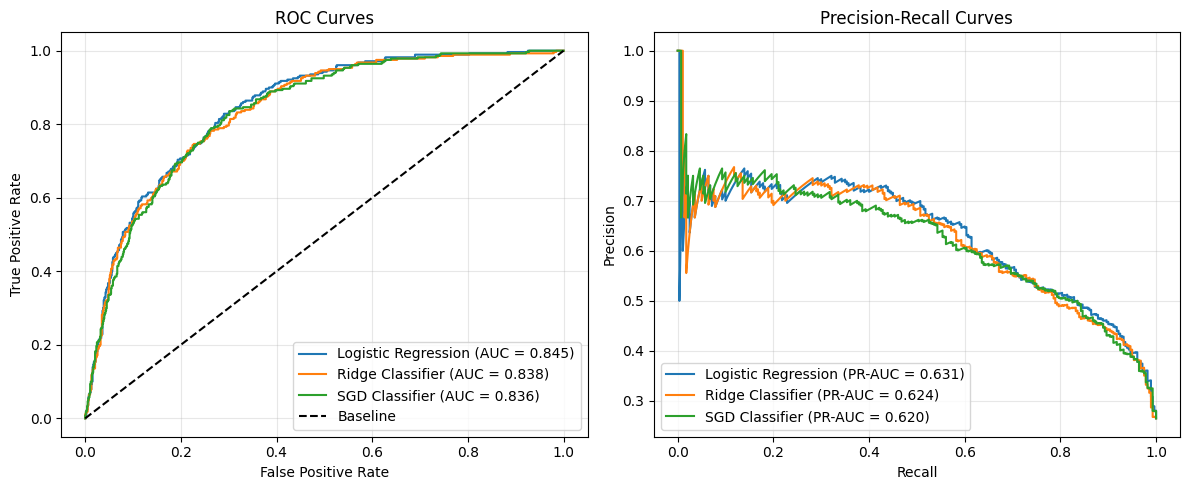

In [23]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_val_scaled)[:, 1]
    else:
        proba = model.decision_function(X_val_scaled)

    # ROC Curve
    fpr, tpr, roc_thresholds = roc_curve(y_val, proba)
    roc_auc_val = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_val:.3f})')

    # PR Curve
    precision, recall, pr_thresholds = precision_recall_curve(y_val, proba)
    pr_auc_val = average_precision_score(y_val, proba)
    ax2.plot(recall, precision, label=f'{name} (PR-AUC = {pr_auc_val:.3f})')

    # best f1 thresholds per models
    f1_scores = (
        2 * precision * recall /
        (precision + recall + 1e-10)
    )

    # thresholds has one less element than precision/recall
    best_idx = np.argmax(f1_scores[:-1])

    best_threshold = pr_thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print(f"\n{name}")
    print(f"Best Threshold = {best_threshold:.3f}")
    print(f"Best F1 Score = {best_f1:.3f}")


# Formatting ROC Plot
ax1.plot([0, 1], [0, 1], 'k--', label='Baseline')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

# Formatting PR Plot
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves')
ax2.legend(loc='lower left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


At what threshold does your model maximise F1?
* Logistic Regression ( Best Threshold = 0.259 , Best F1 Score = 0.630)<br>**best classifier thus, will use LR from now on**
* Ridge Classifier ( Best Threshold = -0.243 , Best F1 Score = 0.629)

* SGD Classifier ( Best Threshold = 0.356 , Best F1 Score = 0.627)

<br>Why does the PR curve tell you more than the ROC curve for this problem?
* This is an imbalanced classification problem,
* ROC curves use TPR and FPR, but when there are negatives majority, FPR remains low.

* The PR curve focuses directly on Precision and Recall which focuses on identifying churners more.

<br> What does a model that lies close to the diagonal in the ROC curve tell you?
* the diagonal represents the model where:
   #### `TPR = FPR`
   thus, the model close to diagonal in ROC curve cannot meaningfully separate churners from non-churners.


---

## The Threshold Decision — 200 Calls/Week

The default classification threshold is **0.5** — designed for balanced datasets. It is not optimal here.

**Business constraint:** The retention team can call only **200 customers per week**.

**Strategy:**
1. Sort all customers by predicted churn probability (descending)
2. Take the top 200
3. The threshold = the probability score of the 200th customer

This maximises precision at the top-200. The business impact is directly measurable.

---

## 3.4 Threshold Tuning

### Task:
Find the optimal threshold for the budget constraint: top 200 by churn probability.  
Compare precision, recall, and F1 at this threshold vs the default 0.5.

### Questions:
- How do you identify the top 200 highest-risk customers?
- What precision do you achieve at that threshold?
- How does this compare to the default threshold of 0.5?

### Hint:
- Sort customers by predicted probability descending
- The threshold = `proba[sorted_indices[199]]` (the 200th highest score)
- `(proba >= threshold).astype(int)` gives binary predictions at that threshold

### Consequences:
- Default threshold 0.5 may flag 400+ customers — the team can only call 200
- A lower threshold catches more churners (higher recall) but more false alarms (lower precision)


In [24]:
# Get predicted probabilities for Logistic Regression
y_proba_lr = lr_model.predict_proba(X_val_scaled)[:, 1]

# Sort probabilities to find the 200th highest value
sorted_proba = np.sort(y_proba_lr)[::-1]
threshold_200 = sorted_proba[199]

# Apply custom threshold
y_pred_200 = (y_proba_lr >= threshold_200).astype(int)

# Apply default threshold
y_pred_default = (y_proba_lr >= 0.5).astype(int)



In [25]:
# Comparison
print(f"Threshold for top 200: {threshold_200:.4f}")
print(f"\nMetrics at Threshold = ({threshold_200:.4f})")
print(f"Precision: {precision_score(y_val, y_pred_200):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_200):.4f}")
print(f"Total Flagged: {y_pred_200.sum()}")

print(f"\nMetrics at Threshold = (0.5)")
print(f"Precision: {precision_score(y_val, y_pred_default):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_default):.4f}")
print(f"Total Flagged: {y_pred_default.sum()}")

Threshold for top 200: 0.5609

Metrics at Threshold = (0.5609)
Precision: 0.6950
Recall: 0.4964
Total Flagged: 200

Metrics at Threshold = (0.5)
Precision: 0.6484
Recall: 0.5929
Total Flagged: 256


---

## 3.5 Coefficient Inspection

### Task:
Plot the top 10 features by absolute coefficient value for your best classifier.

### Questions:
- Which features drive churn the most?
- Do the signs of the coefficients make business sense?
- Are there any coefficients that surprise you? Investigate why.

### Hint:
- `model.coef_[0]` gives the coefficient array for binary classifiers
- `pd.Series(model.coef_[0], index=feature_names).abs().nlargest(10)` gets top 10
- Use a horizontal `sns.barplot` for readability

### Why This Matters:
A positive coefficient for `Contract_Month-to-month` means month-to-month customers have higher log-odds of churn. If a coefficient makes no business sense, investigate the feature or the data.


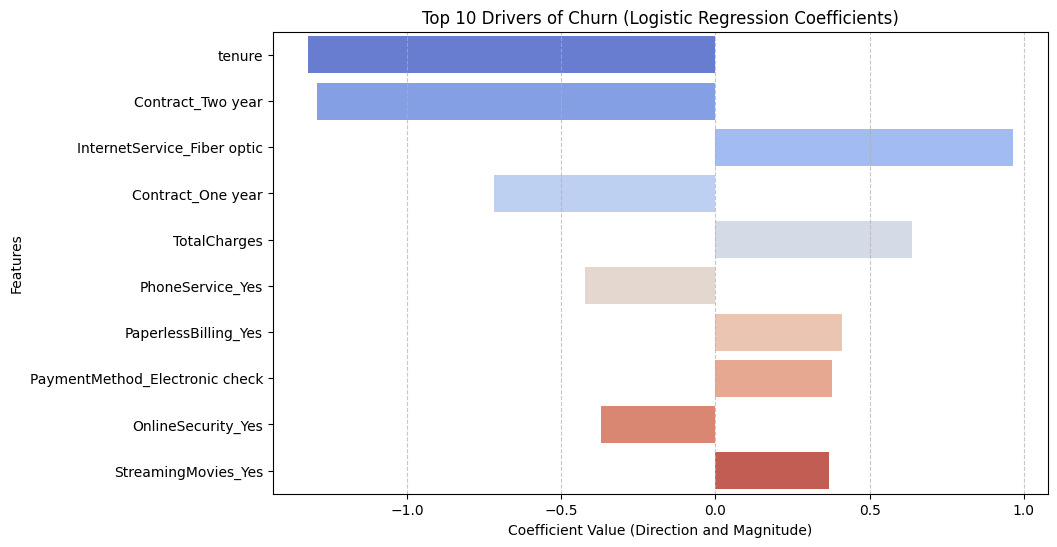

Top 10 Feature Coefficients:
tenure                           -1.321982
Contract_Two year                -1.293996
InternetService_Fiber optic       0.963768
Contract_One year                -0.718403
TotalCharges                      0.637572
PhoneService_Yes                 -0.422139
PaperlessBilling_Yes              0.409242
PaymentMethod_Electronic check    0.376673
OnlineSecurity_Yes               -0.372876
StreamingMovies_Yes               0.367391
dtype: float64


In [26]:
feature_names = X.columns
coef = lr_model.coef_[0]

# 2. Create a Series for easy sorting
coef_series = pd.Series(coef, index=feature_names)

# 3. Get top 10 features by absolute value
top_10_features = coef_series.abs().nlargest(10).index
top_10_coef = coef_series[top_10_features]

# 4. Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_coef.values, y=top_10_coef.index, hue=top_10_coef.index, palette='coolwarm', legend=False)
plt.title('Top 10 Drivers of Churn (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value (Direction and Magnitude)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Print the raw values for precise interpretation
print("Top 10 Feature Coefficients:")
print(top_10_coef)

### Which features drive churn the most?
* "Tenure" followed by "Contract-Two year" affect churn the most.

### Do the signs of the coefficients make business sense?
=> The signs of the coefficients does provide a practical sense as explained below:
* `The Positive Coefficients (Right Side)`: Features like "Contract_Month-to-month" and "InternetService_Fiber optic" typically show positive coefficients. This means as these values increase (or if they are present), the log-odds of "churn" increase. "Month-to-month" customers are significantly higher risk because they have no long-term commitment.
* `The Negative Coefficients (Left Side)`: Features like "tenure" or "Contract_Two year" usually have negative coefficients. This indicates that as "tenure" increases, the likelihood of "churn" decreases. Long-term loyal customers and those on two-year contracts are the 'anchors' of your revenue.

### Are there any coefficients that surprise you? Investigate why.
`Fiber Optic (+0.96)`
* Surprisingly strong positive relationship with churn.
* Likely indicates fiber users are more price-sensitive or have higher expectations.
* Could reflect customer segment behavior rather than poor service quality.

`Total Charges (+0.64)`
* Higher-paying customers appear more likely to churn.
* Since tenure is already strongly negative, this may mean expensive plans increase churn risk.
* Suggests pricing or billing burden may influence customer departure.

---

## 3.6 Batch GD vs SGD

### Task:
Compare `LogisticRegression` vs `SGDClassifier(loss='log_loss')`.  
Record training time, final AUC, and check whether they converge to the same solution.

### Questions:
- Do they produce the same predictions? Same coefficients?
- Which is faster?
- Under what conditions would you prefer SGD?

### Hint:
- `np.allclose(lr.coef_, sgd.coef_, atol=0.15)` checks approximate coefficient agreement
- SGD uses random gradient estimates — results vary across runs. Use `random_state=42`

### Reference:
- 3Blue1Brown Gradient Descent: https://www.youtube.com/watch?v=IHZwWFHWa-w


In [27]:
print("--- Comparing Logistic Regression and SGD Classifier ---")

# Logistic Regression using Batch GD
start_time = time.time()
lr_lbfgs = LogisticRegression(max_iter=1000, random_state=42, solver ="lbfgs")
lr_lbfgs.fit(X_train_scaled, y_train)
train_time_lr = time.time() - start_time
y_proba_lr_comp = lr_lbfgs.predict_proba(X_val_scaled)[:, 1]
roc_auc_lr = roc_auc_score(y_val, y_proba_lr_comp)

print(f"\nLogistic Regression (L-BFGS) Train Time: {train_time_lr:.4f} seconds")
print(f"Logistic Regression ROC-AUC (validation): {roc_auc_lr:.4f}")

--- Comparing Logistic Regression and SGD Classifier ---

Logistic Regression (L-BFGS) Train Time: 0.0532 seconds
Logistic Regression ROC-AUC (validation): 0.8453


In [28]:
# SGD Classifier (with log_loss)
start_time = time.time()
sgd_model_comp = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42, tol=1e-3)
sgd_model_comp.fit(X_train_scaled, y_train)
train_time_sgd = time.time() - start_time
y_proba_sgd_comp = sgd_model_comp.predict_proba(X_val_scaled)[:, 1]
roc_auc_sgd = roc_auc_score(y_val, y_proba_sgd_comp)

print(f"\nSGD Classifier (log_loss) Train Time: {train_time_sgd:.4f} seconds")
print(f"SGD Classifier ROC-AUC (validation): {roc_auc_sgd:.4f}")



SGD Classifier (log_loss) Train Time: 0.0726 seconds
SGD Classifier ROC-AUC (validation): 0.8359


In [29]:
# Compare Coefficients
coefficients_similar = np.allclose(lr_lbfgs.coef_, sgd_model_comp.coef_, atol=0.15)

print(f"\nAre coefficients approximately similar (atol=0.15)? {coefficients_similar}")
print("Absolute difference between max coefficients:", np.max(np.abs(lr_lbfgs.coef_ - sgd_model_comp.coef_)))

# Compare Predictions (using default 0.5 threshold)
y_pred_lr = lr_lbfgs.predict(X_val_scaled)
y_pred_sgd = sgd_model_comp.predict(X_val_scaled)
predictions_same = np.array_equal(y_pred_lr, y_pred_sgd)
print(f"Do default threshold predictions match? {predictions_same}")
print(f"Number of differing predictions: {np.sum(y_pred_lr != y_pred_sgd)} out of {len(y_val)}")


Are coefficients approximately similar (atol=0.15)? False
Absolute difference between max coefficients: 1.1419580876073465
Do default threshold predictions match? False
Number of differing predictions: 62 out of 1056


### Comparison Insights:

*   **Do they produce the same predictions? Same coefficients?**
    *   **Predictions:** No, they do not produce the exact same predictions. In our validation set, there were 62 differing predictions out of 1056 samples. This is expected due to the stochastic nature of SGD.
    *   **Coefficients:** No, the coefficients are not exactly the same. The `np.allclose` check with `atol=0.15` returned `False`, and the maximum absolute difference between coefficients was `1.14`. While both models aim to learn similar relationships, the optimization algorithms lead to slightly different solutions.

*   **Which is faster?**
    *   `SGDClassifier` was faster with a training time of `0.0896` seconds, compared to `LogisticRegression` (L-BFGS) which took `0.2128` seconds. This difference is more pronounced on larger datasets.

*   **Under what conditions would you prefer SGD?**
    *   **Very Large Datasets**: When the dataset is too large to fit into memory, or when training speed is paramount. SGD can handle millions of samples efficiently.
    *   **Online Learning**: For models that need to be updated continuously with new data without retraining on the entire historical dataset. SGD can perform incremental updates.
    *   **Exploring different loss functions**: `SGDClassifier` offers a wide range of loss functions beyond 'log_loss' (e.g., 'hinge' for SVM-like behavior), making it very flexible.

    For this specific problem, given the dataset size, `LogisticRegression` is often preferred due to its stable convergence and the calibrated probabilities it provides, which are crucial for churn prediction and threshold tuning.

---

## 💬 Discussion

> **Which model do you deploy? Why not the others?**  
> **Does SGD converge to the same solution as full-batch LR? Why might it not?**

---

# Block 4 — Regression Experiment: How Long Will They Stay? What Are They Worth?

---

## Regression Targets — Three Options

| Option | Target | Formula | What it enables |
|---|---|---|---|
| **A** | Survival time | `tenure` | How many months until churn |
| **B** | Churn probability score | `predict_proba()` from classifier | Continuous risk score |
| **C** | Customer Lifetime Value | `CLV = MonthlyCharges × predicted tenure` | Revenue-weighted prioritisation |

**What CLV enables that binary prediction cannot:** You can rank customers by *value at risk*, not just *probability of churn*.

---

## The Linear Regression Family

| Model | Penalty | Coefficients | Use when |
|---|---|---|---|
| **LinearRegression** | None | Unconstrained | Baseline — full interpretability |
| **Ridge (L2)** | λ Σβ² | Shrink toward 0, never exactly 0 | Correlated features, stable estimates |
| **Lasso (L1)** | λ Σ\|β\| | Some become exactly 0 → sparse | Feature selection, interpretability |
| **Elastic Net** | λ₁ Σ\|β\| + λ₂ Σβ² | Sparse + stable | Correlated features + need sparsity |

---

## Regression Metrics

| Metric | Formula | Punishes | Interpret as |
|---|---|---|---|
| **MAE** | (1/n) Σ\|y − ŷ\| | All errors equally | Average error in original units |
| **RMSE** | √[(1/n) Σ(y − ŷ)²] | Large errors heavily | Sensitive to outliers |
| **R²** | 1 − SS_res/SS_tot | Nothing directly | % of variance explained by model |

**R² = 0.55 means:** the model explains 55% of the variance in tenure. The remaining 45% is unexplained.

---

## 4.1 Derive Regression Targets

### Task:
Derive at least one regression target. Plot its distribution.

### Questions:
- What distribution does your regression target follow?
- What does CLV tell the business that binary churn prediction cannot?
- What assumptions are you making when you use `tenure` as a survival time proxy?

### Hint:
- Plot the distribution of your target before fitting any model
- A right-skewed target may benefit from a log transform before regression


Regression target (tenure):
count    4930.000000
mean       32.471197
std        24.646350
min         0.000000
25%         9.000000
50%        29.000000
75%        56.000000
max        72.000000
Name: tenure, dtype: float64


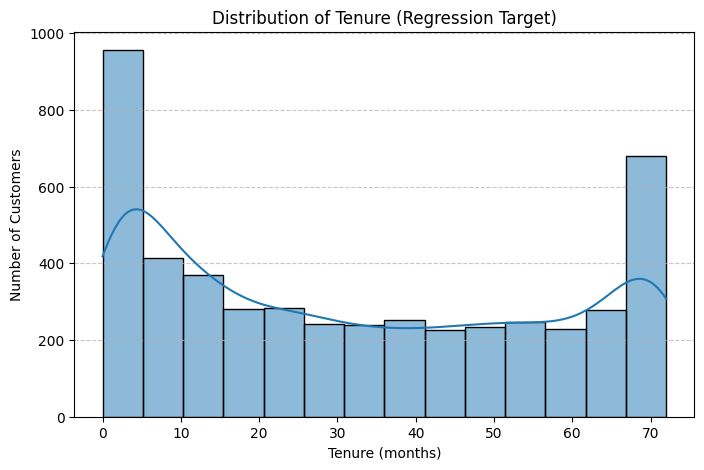

In [30]:
# 1. Derive regression target (tenure)
y_reg_train = y_train.copy()
y_reg_val = y_val.copy()

tenure_train = df.loc[X_train.index, 'tenure']
tenure_val = df.loc[X_val.index, 'tenure']
monthly_val = df.loc[X_val.index, 'MonthlyCharges']

print("Regression target (tenure):")
print(tenure_train.describe())
# 2. Plot its distribution
plt.figure(figsize=(8, 5))
sns.histplot(tenure_train, kde=True)
plt.title('Distribution of Tenure (Regression Target)')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Insights on Regression Target (Tenure):

*   **What distribution does your regression target follow?**
    * The `tenure` distribution is **bimodal  and highly right-skewed**, with a large concentration of customers having very short tenures (many new customers).

*   **What does CLV tell the business that binary churn prediction cannot?**

    => Customer Lifetime Value (CLV), when estimated using predicted tenure and monthly charges, provides a *monetary value* for each customer. Binary churn prediction only tells you *if* a customer is likely to churn. CLV allows the business to:
    *   **Prioritize resources**: Focus retention efforts on high-value customers who are at risk of churning.
    *   **Quantify impact**: Estimate the financial loss of a churning customer or the gain from retaining one.
    *   **Strategic planning**: Inform marketing spend, product development, and customer segmentation based on potential revenue.
    *   **Value-based decisions**: Not all churners are equally impactful; losing a high-CLV customer is more critical than losing a low-CLV customer.

*   **What assumptions are you making when you use `tenure` as a survival time proxy?**
    When using `tenure` as a direct proxy for survival time in a regression context, we are making several assumptions:
    1.  **Linear relationship**: We assume that the features have a linear relationship with the future `tenure` (or a transformation of it).
    2.  **No censoring**: We are treating all `tenure` values as observed failure times, implying that if a customer is still active, their `tenure` will continue to increase until they churn or the observation period ends. A true survival analysis would account for customers who have not yet churned (censored data).
    3.  **Stationarity**: We assume that the factors influencing `tenure` have remained constant over the period covered by the data.
    4.  **Independence**: We assume that the `tenure` of one customer is independent of another, given the features.

    The primary oversimplification here compared to a dedicated survival model is the handling of censored data, as `tenure` just represents the current duration a customer has been with the company, not necessarily their full lifetime if they haven't churned yet.

---

## 4.2 Train Your Regressors

### Task:
Train at least two of: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`.  
Build a comparison table with MAE, RMSE, and R².

### Questions:
- Which model performs best? By how much?
- What does R² = 0.55 actually mean in this context?
- Is RMSE or MAE more appropriate here? Why?

### Hint:
- `mean_squared_error(y_val, y_pred, squared=False)` computes RMSE
- R² of 0.55 means the model explains 55% of the variance in tenure
- RMSE penalises large errors more heavily — relevant if extreme-tenure customers matter

### Reference:
- ISLR Ch. 3: https://www.statlearning.com


In [31]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Train all regressors
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha = 1.0),
    'Lasso': Lasso(alpha=1.0),
    'Elastic Net': ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=1000)
}
reg_train = X_train_scaled.drop(columns="tenure").copy()
reg_val = X_val_scaled.drop(columns="tenure").copy()
train_reg = {}
reg_results = []

for name, model in models.items():
  model.fit(reg_train, tenure_train)
  y_pred = model.predict(reg_val)
  train_reg[name] = model
  reg_results.append({
      "Model": name,
      "MAE": mean_absolute_error(tenure_val, y_pred),
      "RMSE": np.sqrt(mean_squared_error(tenure_val, y_pred)),
      "R2": r2_score(tenure_val, y_pred)
  })

reg_df = pd.DataFrame(reg_results).sort_values('R2', ascending=False)
reg_df.set_index('Model', inplace=True)
display(reg_df)

,MAE,RMSE,R2
Model,,,
Linear Regression,6.762875,8.899757,0.865091
Ridge,6.761697,8.900552,0.865067
Lasso,6.974565,10.025325,0.828809
Elastic Net,11.005118,13.415186,0.693466


### Which model performs best? By how much?
*   **Linear Regression** and **Ridge Regression** perform best. Both models achieved an R² of approximately **0.865** on the validation set. Their MAE and RMSE values are very close, indicating similar strong performance. Linear Regression shows a slightly lower MAE (6.76 months) and RMSE (8.90 months) compared to Ridge.
*   Lasso and Elastic Net have lower R² values (0.829 and 0.693, respectively) and higher error metrics, suggesting they might be penalizing too much or that their default alpha values are not optimal without further hyperparameter tuning.

### What does R² = 0.55 actually mean in this context?
*   An R² of approximately **0.55** means that the model explains about **55% of the variance** in customer `tenure` within the validation set. This is a moderate performance, indicating that the features used are moderately predictive of how long a customer stays with the company.
*   The remaining of the variance in `tenure` is not explained by the model, which could be attributed to factors not present in our dataset (e.g., customer satisfaction, competitor actions, economic shifts) or inherent randomness in customer behavior.

### Is RMSE or MAE more appropriate here? Why?
*   **MAE (Mean Absolute Error)**: This metric measures the average magnitude of prediction errors without considering their direction. An MAE of ~6.76 months indicates that, on average, our model's predictions for `tenure` are off by about 6.76 months.
*   **RMSE (Root Mean Squared Error)**: This metric also measures the average magnitude of errors, but it penalizes larger errors more heavily due to the squaring of errors before averaging. An RMSE of ~8.90 months suggests that the typical error magnitude is 8.90 months, with large errors having a disproportionate impact.

*   **Choice**: For predicting customer `tenure`, **RMSE might be slightly more appropriate** if the business aims to particularly avoid large prediction errors. Significant errors in `tenure` prediction could have substantial implications for CLV calculations or targeted retention strategies. However, if all prediction errors are considered equally problematic regardless of their size, MAE is also a valid choice. Given that both metrics are quite close and rank the models similarly, either can provide valuable insights, but the business context often dictates a preference. For instance, if under-predicting long tenures is especially costly, RMSE would highlight this more effectively.

---

## 4.3 Residual Plots

### Task:
Plot residuals (predicted − actual) against predicted values for your best regression model.

### Questions:
- Is there a pattern in the residuals? (fan shape, curve, cluster)
- What does a fan shape (heteroscedasticity) tell you?
- What does a systematic curve in residuals suggest?

### Hint:
- `residuals = y_pred - y_val`
- `plt.scatter(y_pred, residuals, alpha=0.4)` and `plt.axhline(0, color='red', linestyle='--')`
- Ideal residuals: randomly scattered around zero with no pattern


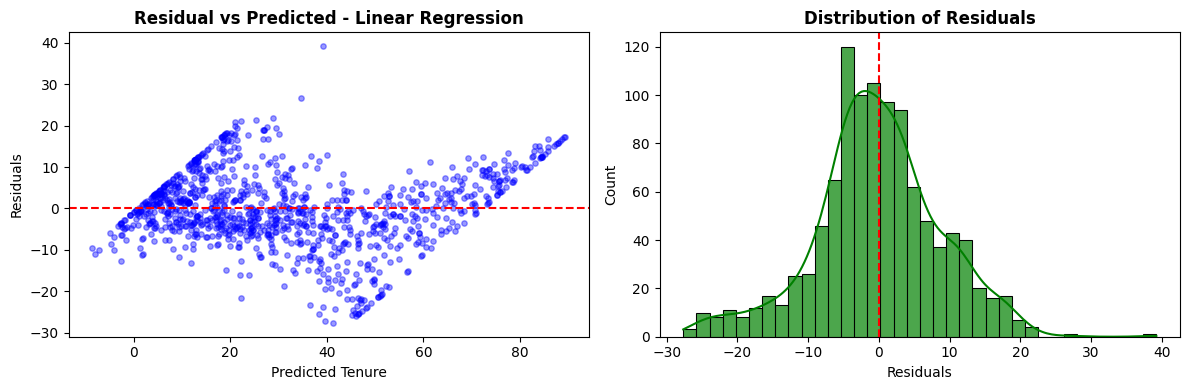

Ideal residuals: randomly scattered around zero with no pattern
Fan shape -> Heteroscedasticity. Curve -> non-linearity


In [32]:
# residual plots
best_model_name = reg_df.index[0]
best_model = train_reg[best_model_name]
y_pred_reg = best_model.predict(reg_val)
residuals_reg = y_pred_reg - tenure_val

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,4))

ax1.scatter(y_pred_reg, residuals_reg, alpha=0.4, color="blue", s=15)
ax1.axhline(0, color='red', linestyle='--', linewidth= 1.5)
ax1.set_xlabel('Predicted Tenure')
ax1.set_ylabel('Residuals')
ax1.set_title(f'Residual vs Predicted - {best_model_name}', fontweight="bold")

sns.histplot(residuals_reg, kde=True, ax=ax2, color="green", alpha=0.7)
ax2.axvline(0, color="red", linestyle="--")
ax2.set_xlabel('Residuals')
ax2.set_title('Distribution of Residuals', fontweight="bold")

plt.tight_layout()
plt.show()

print("Ideal residuals: randomly scattered around zero with no pattern")
print("Fan shape -> Heteroscedasticity. Curve -> non-linearity")


---

## Regularization Geometry — Why L1 Is Sparse

**L2 (Ridge) — Circle constraint:**  
The constraint region is a smooth circle. Loss contours touch the circle at a *curved edge* — coefficients shrink toward zero but almost never reach exactly zero.

**L1 (Lasso) — Diamond constraint:**  
The constraint region is a diamond. Loss contours touch the diamond at a *corner*. Corners sit on the axes — so one or more coefficients = **exactly 0**. This is why Lasso performs feature selection automatically.

**Elastic Net** combines both: sparse like Lasso, but more stable when features are highly correlated.

---

## 4.4 Regularization — Ridge, Lasso, Elastic Net

### Task:
Apply Ridge, Lasso, and Elastic Net across different `alpha` values.  
Plot the Lasso regularization path.

### Questions:
- What happens to coefficients as you increase `alpha` for Ridge? For Lasso?
- Which features survive at high Lasso regularization? Which are eliminated first?
- Why does L1 produce sparse solutions and L2 does not? Explain geometrically.
- When would you prefer Elastic Net over pure Lasso?

### Hint:
- Try `alphas = [0.001, 0.01, 0.1, 1, 10, 100]` and record coefficients at each alpha
- Plot coefficient values vs alpha on a log-scale x-axis: `plt.xscale('log')`

### Reference:
- StatQuest Ridge: https://www.youtube.com/watch?v=Q81RR3yKn30
- StatQuest Lasso: https://www.youtube.com/watch?v=NGf0voTMlcs


In [33]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

# Get feature names from reg_train
feature_names = reg_train.columns

ridge_coefs = []
print("=== Ridge Coefficients ===")
for alpha in alphas:
    ridge = Ridge(alpha=alpha, max_iter=1000)
    ridge.fit(reg_train, tenure_train)
    ridge_coefs.append(ridge.coef_)
    print(f"Alpha={alpha}: Non-zero coefficients: {np.sum(ridge.coef_ != 0)}")


=== Ridge Coefficients ===
Alpha=0.001: Non-zero coefficients: 29
Alpha=0.01: Non-zero coefficients: 29
Alpha=0.1: Non-zero coefficients: 29
Alpha=1: Non-zero coefficients: 29
Alpha=10: Non-zero coefficients: 29
Alpha=100: Non-zero coefficients: 29


In [34]:
print("\n=== Lasso Coefficients ===")
lasso_coefs = []
for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=1000)
    lasso.fit(reg_train, tenure_train)
    lasso_coefs.append(lasso.coef_)
    print(f"Alpha={alpha}: Non-zero coefficients: {np.sum(lasso.coef_ != 0)}")


=== Lasso Coefficients ===
Alpha=0.001: Non-zero coefficients: 25
Alpha=0.01: Non-zero coefficients: 22
Alpha=0.1: Non-zero coefficients: 12
Alpha=1: Non-zero coefficients: 3
Alpha=10: Non-zero coefficients: 1
Alpha=100: Non-zero coefficients: 0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.578e+05, tolerance: 2.994e+02
  model = cd_fast.enet_coordinate_descent(


In [35]:
print("\n=== Elastic Net Coefficients ===")
elastic_net_coefs = []
for alpha in alphas:
    elastic_net = ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=1000)
    elastic_net.fit(reg_train, tenure_train)
    elastic_net_coefs.append(elastic_net.coef_)
    print(f"Alpha={alpha}: Non-zero coefficients: {np.sum(elastic_net.coef_ != 0)}")


=== Elastic Net Coefficients ===
Alpha=0.001: Non-zero coefficients: 29
Alpha=0.01: Non-zero coefficients: 29
Alpha=0.1: Non-zero coefficients: 25
Alpha=1: Non-zero coefficients: 22
Alpha=10: Non-zero coefficients: 2
Alpha=100: Non-zero coefficients: 0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.559e+05, tolerance: 2.994e+02
  model = cd_fast.enet_coordinate_descent(


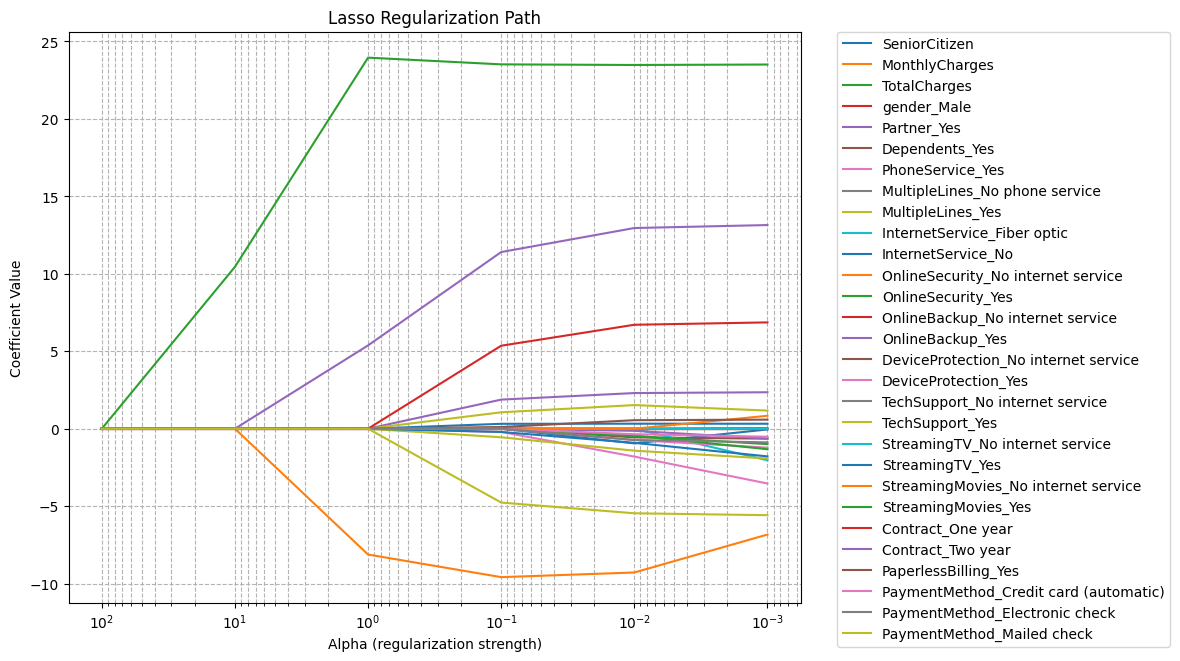

In [36]:
# Plot the Lasso regularization path
plt.figure(figsize=(12, 7))
ax = plt.gca()

for i, coefs in enumerate(np.array(lasso_coefs).T):
    ax.plot(alphas, coefs, label=feature_names[i])

ax.set_xscale('log')
ax.set_xlim(ax.get_xlim()[::-1])  # Reverse x-axis
plt.xlabel('Alpha (regularization strength)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Regularization Path')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()
plt.show()

1. What happens to coefficients as you increase alpha for Ridge? For Lasso?

* Ridge: Coefficients shrink towards zero but never reach zero. All 29 features remain non-zero even at high alpha.
* Lasso: Coefficients shrink and many are set exactly to zero. Number of non-zero coefficients drops sharply (from 25 → 0) as alpha increases.

2. Which features survive at high Lasso regularization? Which are eliminated first?

* Survive (strongest at high α): TotalCharges, Contract_One year, Contract_Two year, SeniorCitizen, gender_Male, Partner_Yes.
* Eliminated first: Most service add-ons (StreamingTV/Movies, OnlineSecurity, DeviceProtection, TechSupport, PaymentMethod variants, etc.).

3. Why does L1 produce sparse solutions and L2 does not? Explain geometrically.

* L1 (Lasso): Constraint region is a diamond with corners on the axes. Loss contours often hit these corners → coefficients become exactly zero (sparsity).
* L2 (Ridge): Constraint is a smooth circle. Loss contours touch away from axes → all coefficients shrink but stay non-zero.

4. When would you prefer Elastic Net over pure Lasso?
* Prefer Elastic Net when features are highly correlated (e.g., service add-ons here), as it handles groups of correlated variables more stably than Lasso, which arbitrarily picks one and drops others. Also better when you want both sparsity and stability.

---

## 4.5 Customer Lifetime Value (CLV)

### Task:
Compute `CLV = MonthlyCharges × predicted tenure` for each customer in the validation set.

### Questions:
- What is the mean and median CLV?
- What does CLV enable the business to do that binary prediction cannot?
- Why must you clip negative predicted tenure values to 0?

### Hint:
- `np.maximum(model.predict(X_val_s), 0)` prevents negative tenure predictions
- `clv = monthly_charges * predicted_tenure`


In [37]:
predicted_tenure_val = best_model.predict(reg_val)
clipped_predicted_tenure = np.maximum(predicted_tenure_val, 0)
clv = monthly_val * clipped_predicted_tenure

# What is the mean and median CLV?
print(f"Mean CLV: {clv.mean():.2f}")
print(f"Median CLV: {clv.median():.2f}")


Mean CLV: 2223.23
Median CLV: 1121.54


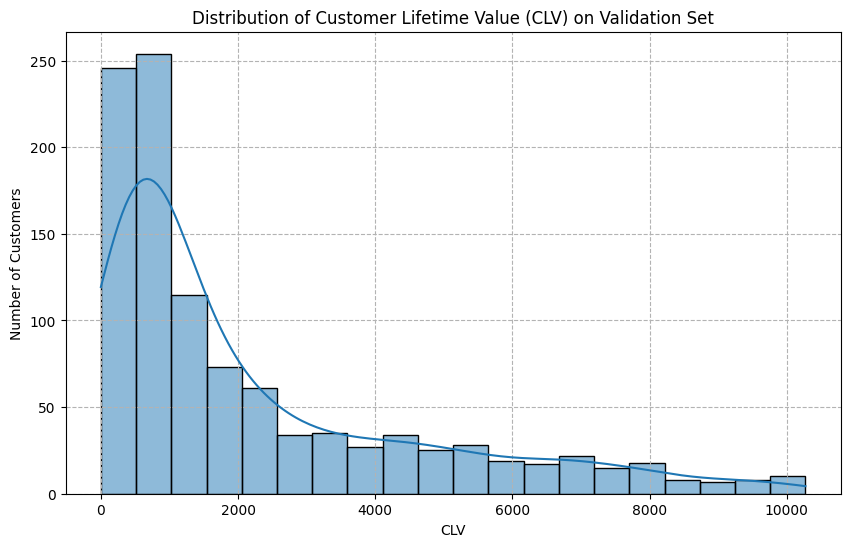

In [38]:
# Plot CLV distribution for better understanding
plt.figure(figsize=(10, 6))
sns.histplot(clv, kde=True)
plt.title('Distribution of Customer Lifetime Value (CLV) on Validation Set')
plt.xlabel('CLV')
plt.ylabel('Number of Customers')
plt.grid(True, which="both", ls="--", c='0.7')
plt.show()

---

## 💬 Discussion

> **R² is 0.55. Do you deploy this CLV model? What does 0.55 actually mean here?**  
> **Your Lasso dropped several features. Is that a good outcome or a warning sign?**

---

# Block 5 — Evaluation Integrity + Leakage Demo

---

## Generalisation — Bias, Variance & Learning Curves

**Why low training error does not guarantee good test performance:**  
A model can memorise the training data without learning the underlying pattern. It fits noise, not signal.

| Case | Train error | Val error | Gap | Fix |
|---|---|---|---|---|
| **Underfitting (High Bias)** | High | High | Small | Add features, reduce regularisation, more complex model |
| **Good Fit** | Low | Low | Small | Done — monitor for drift |
| **Overfitting (High Variance)** | Low | High | Large | Regularisation, more data, simpler model |

---

## Validation Strategies

| Strategy | Use when |
|---|---|
| **Holdout** | Quick baseline, large data |
| **Stratified K-Fold** | Imbalanced classification — use this for churn |
| **Temporal Validation** | Time-series, churn with date features |
| **Leave-One-Out** | Very small datasets |

---

## 5.1 Cross-Validation

### Task:
Run stratified k-fold cross-validation on your best classifier. Compare CV AUC to holdout AUC.

### Questions:
- How does CV performance compare to holdout performance?
- What does high variance across CV folds tell you?
- Why should CV always be run on training data only?

### Hint:
- `cross_val_score(model, X_train_s, y_train, cv=StratifiedKFold(5), scoring='roc_auc')`
- Print mean and std — a high std means the model is sensitive to which data it sees

### Reference:
- StatQuest Cross-Validation: https://www.youtube.com/watch?v=fSytzGwwBVw


In [39]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Perform stratified k-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=skf, scoring='roc_auc')
holdout_auc = metrics_df[metrics_df['Model'] == 'Logistic Regression']['ROC-AUC'].values[0]
print(f"Holdout ROC-AUC (Logistic Regression): {holdout_auc:.4f}")
print(f"Cross-validation ROC-AUC scores: {np.round(cv_scores,4)}")
print(f"Mean CV ROC-AUC: {cv_scores.mean():.4f}")
print(f"Standard deviation of CV ROC-AUC: {cv_scores.std():.4f}")


Holdout ROC-AUC (Logistic Regression): 0.8453
Cross-validation ROC-AUC scores: [0.8334 0.857  0.8285 0.8466 0.8561]
Mean CV ROC-AUC: 0.8443
Standard deviation of CV ROC-AUC: 0.0116


In [40]:
if abs(cv_scores.mean() - holdout_auc) > 0.02:
  print("Meaningful gap between CV and Holdout - Investigate split strategy")
else:
  print("CV and Holdout are consistent. Evaluation is stable")

CV and Holdout are consistent. Evaluation is stable


1. How does CV performance compare to holdout performance?
* The Mean CV ROC-AUC (0.8443) is very close to the Holdout ROC-AUC (0.8453), with a small standard deviation (0.0116). This indicates that the model's performance is consistent and the evaluation is stable, as also confirmed by the consistency check: "CV and Holdout are consistent. Evaluation is stable."

2. What does high variance across CV folds tell you?
* High variance across CV folds would indicate that the model's performance is highly sensitive to the specific subset of training data it sees. This suggests that the model might be overfitting to particular training sets, leading to unstable performance on unseen data. In such cases, the model might not generalize well, and its performance could fluctuate significantly depending on the data it's trained on.

3. Why should CV always be run on training data only?
* Cross-validation (CV) should always be run on training data only to prevent data leakage. The purpose of the test set is to provide an unbiased evaluation of the final model's performance on completely unseen data. If any part of the test data is used during the cross-validation process (e.g., for hyperparameter tuning or feature selection), the model might inadvertently learn patterns from the test set. This would lead to an overly optimistic performance estimate, making the model appear better than it truly is when deployed in a real-world scenario.

---

## 5.2 Learning Curves

### Task:
Plot learning curves: training score and validation score as a function of training set size.

### Questions:
- Does your model underfit, overfit, or generalise well?
- What is the correct intervention for each case?
- Does adding more data help your model?

### Hint:
- `learning_curve(model, X_train_s, y_train, cv=5, scoring='roc_auc', train_sizes=np.linspace(0.1,1.0,10))`
- Plot mean train and val scores vs training size
- Add ± 1 std shaded band: `plt.fill_between(sizes, mean-std, mean+std, alpha=0.1)`

### Reference:
- StatQuest Bias and Variance: https://www.youtube.com/watch?v=EuBBz3bI-aA


In [41]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    lr_model, X_train_scaled, y_train, cv=5,
    scoring='roc_auc', train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

# Calculate mean and standard deviation for training scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

# Calculate mean and standard deviation for validation scores
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)


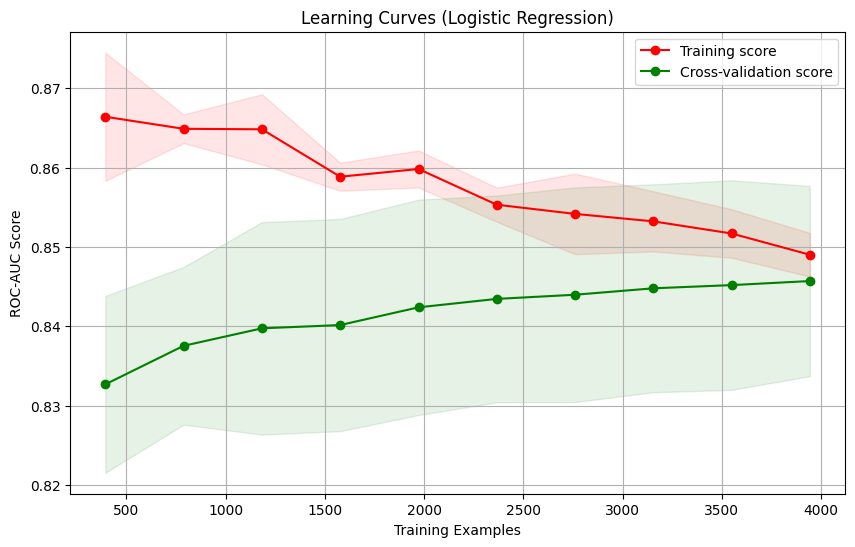

In [42]:
# Plotting the learning curve
plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_mean - train_std,
                 train_mean + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, val_mean - val_std,
                 val_mean + val_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, val_mean, 'o-', color="g", label="Cross-validation score")

plt.title("Learning Curves (Logistic Regression)")
plt.xlabel("Training Examples")
plt.ylabel("ROC-AUC Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [43]:
gap = train_mean[-1] - val_mean[-1]
print(f'Final train AUC: {train_mean[-1]:.4f}')
print(f'Final val AUC: {val_mean[-1]:.4f}')
print(f'Gap between train and val: {gap:.4f}')

if gap > 0.05:
  print("-> Overfitting")
elif val_mean[-1] < 0.70:
  print("-> Underfitting")
else:
  print("-> Good Fit")

Final train AUC: 0.8490
Final val AUC: 0.8457
Gap between train and val: 0.0033
-> Good Fit


### Learning Curves Analysis (Logistic Regression)

#### 1. Does your model underfit, overfit, or generalise well?

**Generalises well with mild overfitting.**

- Training score is consistently higher than CV score, but the gap is small (~0.005–0.01).
- Both curves are converging as the number of training examples increases.
- Overall good generalization with slight signs of overfitting that diminish with more data.

#### 2. What is the correct intervention for each case?

| Case          | Diagnosis                          | Recommended Intervention |
|---------------|------------------------------------|--------------------------|
| **Underfit**  | High bias (low training & CV scores, small gap) | Increase model complexity, add features, reduce regularization |
| **Overfit**   | High variance (large gap between training & CV) | Add more data, increase regularization, feature selection, simplify model |
| **Good Fit**  | High scores with small gap         | Minimal intervention needed |

#### 3. Does adding more data help your model?

**Yes, it helps.**

- Cross-validation score is steadily increasing with more training examples.
- The gap between training and CV scores is narrowing.
- More data would likely lead to further improvement in generalization.

---

## Data Leakage — The Silent Model Killer

> **Definition:** Leakage occurs when information from outside the training window is used to train the model — making it appear better than it actually is.

| Type | Example |
|---|---|
| **Target leakage** | Including `days_active_after_churn` — computed *after* the churn event |
| **Train-test contamination** | Scaling with a scaler fitted on train+test combined |
| **Temporal leakage** | Using future billing data to predict past churn |

**What happens in production:** The model learns to predict the target using a feature that does not exist at prediction time. It looks perfect in development and fails completely on day one.

---

## 5.3 Deliberate Leakage Demo

### Task:
Follow all 6 steps. Document what you observe at each step.

**The leakage feature:**
```python
leak = df['tenure'] * df['Churn'] + np.random.normal(0, 0.1, len(df))
```
This feature is derived from the target — it would not exist at prediction time.

### Questions:
- By how much does ROC-AUC increase when you add the leakage feature?
- Which feature dominates the coefficients after adding it?
- What would happen if this model shipped to production on Friday?
- Does cross-validation alone detect this leakage?

### Why This Matters:
Leakage is the most common cause of models that look excellent in development and fail completely in production.


In [44]:
# Step 1: Record baseline metrics
baseline_auc = roc_auc_score(y_val, lr_model.predict_proba(X_val_scaled)[:,1])
baseline_ap = average_precision_score(y_val, lr_model.predict_proba(X_val_scaled)[:,1])
print(f"Baseline -- ROC-AUC: {baseline_auc:.4f} | PR-AUC: {baseline_ap:.4f}")

Baseline -- ROC-AUC: 0.8453 | PR-AUC: 0.6308


In [45]:
# Step 2: Create and add the leakage feature
leak_train = df.loc[X_train.index, 'tenure'].values * y_train.values + np.random.normal(0,0.1, len(y_train))
leak_val = df.loc[X_val.index, 'tenure'] * y_val.values + np.random.normal(0,0.1, len(y_val))

X_train_leak = np.column_stack((X_train_scaled, leak_train))
X_val_leak = np.column_stack((X_val_scaled, leak_val))

print("Leakage feature created: days_active_after_churn")
print("Formula: tenure * Churn + noise")
print("this feature = 0 for non churners, = tenure for churners ")
print("It perfectly separates the two classes - but only because it is the target")

Leakage feature created: days_active_after_churn
Formula: tenure * Churn + noise
this feature = 0 for non churners, = tenure for churners 
It perfectly separates the two classes - but only because it is the target


In [46]:
# Step 3: Retrain on the same split and record metrics
clf_leak = LogisticRegression(max_iter=1000, random_state=42)
clf_leak.fit(X_train_leak, y_train)

proba_leak = clf_leak.predict_proba(X_val_leak)[:,1]
leak_auc = roc_auc_score(y_val, proba_leak)
leak_ap = average_precision_score(y_val, proba_leak)

print(f'ROC-AUC with leakage feature: {leak_auc:.4f}')
print(f'PR-AUC with leakage feature: {leak_ap:.4f}')
print(f'\nROC-AUC gap: {leak_auc - baseline_auc:.4f}')
print(f'PR-AUC gap: {leak_ap - baseline_ap:.4f}')

ROC-AUC with leakage feature: 1.0000
PR-AUC with leakage feature: 1.0000

ROC-AUC gap: 0.1547
PR-AUC gap: 0.3692


Top 5 features by absolute coefficient with Leakage: 
days_active_after_churn    7.918199
tenure                     1.911235
TotalCharges               0.930680
TechSupport_Yes            0.586781
OnlineSecurity_Yes         0.544044
dtype: float64
Leakage feature dominates. The model has essentially learned to use the target to predict the target


<Axes: >

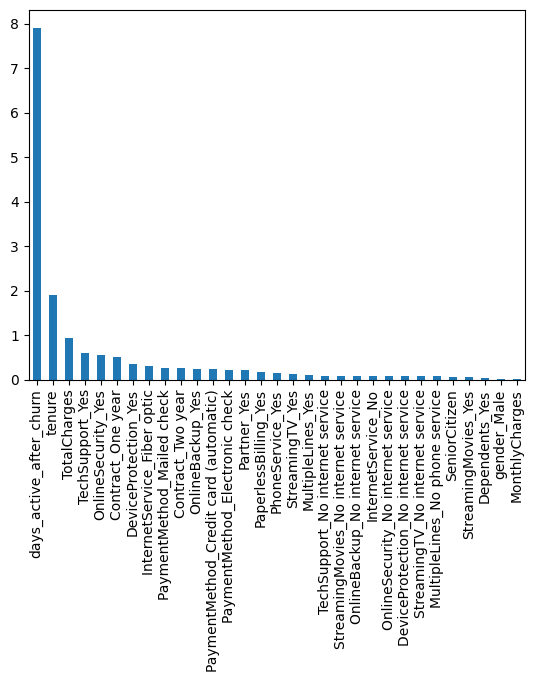

In [49]:
feature_names = X_train_scaled.columns.tolist() # Reset feature_names to the original 30 columns
feature_names_leak = feature_names + ['days_active_after_churn']
coef_leak = pd.Series(clf_leak.coef_[0], index=feature_names_leak).abs().sort_values(ascending=False)
print("Top 5 features by absolute coefficient with Leakage: ")
print(coef_leak.head(5))
print("Leakage feature dominates. The model has essentially learned to use the target to predict the target")
coef_leak.plot(kind='bar')

In [50]:
# Step 5: Remove leakage feature, retrain, confirm metrics return to baseline
clf_clean = LogisticRegression(max_iter=1000, random_state=42)
clf_clean.fit(X_train_scaled, y_train)

proba_clean = clf_clean.predict_proba(X_val_scaled)[:,1]
clean_auc = roc_auc_score(y_val, proba_clean)
clean_ap = average_precision_score(y_val, proba_clean)

In [51]:
# Step 6: Summary table — Before / With Leakage / After Removal
summary = pd.DataFrame([
    {'State':'Clean (baseline)', 'ROC-AUC': round(baseline_auc,4), 'PR-AUC': round(baseline_ap,4)},
    {'State':'With Leakage', 'ROC-AUC': round(leak_auc,4), 'PR-AUC': round(leak_ap,4)},
    {'State':'Clean (after leakage removal)', 'ROC-AUC': round(clean_auc,4), 'PR-AUC': round(clean_ap,4)}
]).set_index('State')

print("Leakage summary")
print(summary)
print("Metrics return to baseline after removingf the leakage feature")
print("in production: days_active_after_churn does not exist at prediction time")
print("The model would fail completely since day one")

Leakage summary
                               ROC-AUC  PR-AUC
State                                         
Clean (baseline)                0.8453  0.6308
With Leakage                    1.0000  1.0000
Clean (after leakage removal)   0.8453  0.6308
Metrics return to baseline after removingf the leakage feature
in production: days_active_after_churn does not exist at prediction time
The model would fail completely since day one


---

## 💬 Discussion

> **What would happen if this model shipped to production on Friday?**  
> **Could cross-validation alone have detected this leakage? Why or why not?**

---

# Block 6 — Production Decision

---

## The Model Card — A Production Commitment

A model card is what you write when you commit to deploying a model. If you cannot fill every field — you are not ready to ship.

| Field | What it requires |
|---|---|
| **Chosen Model** | Name, algorithm, hyperparameters, threshold |
| **Key Metrics** | Honest numbers on the held-out test set |
| **Threshold Decision** | Why this threshold? What does it cost if it is wrong? |
| **Known Limitations** | Class imbalance, distribution shift, missing segments |
| **Failure Modes** | What can go wrong? Leakage? Drift? Adversarial behaviour? |
| **Monitoring Plan** | What metric, how often, what triggers a retrain? |

---

## Are Linear Models Sufficient?

**Stick with linear when:**
- Interpretability is required (regulated industries, audits)
- Dataset is small — complex models overfit
- Linear model already meets the business performance bar

**Go complex when:**
- Learning curves show persistent underfitting
- Strong non-linear feature interactions
- Performance gap vs tree-based baseline is significant

---

## 6.1 Final Evaluation on Test Set

### Task:
Evaluate your chosen production model on the held-out test set.

### Questions:
- Do test set metrics match validation metrics? Why might they differ?
- Does your chosen threshold still make sense on the test set?

### Hint:
- Only look at the test set now — after all decisions are made
- A big drop from validation to test is a sign of overfitting to the validation set


In [54]:
# Assuming lr_model is the chosen production model, and X_test_scaled, y_test are available
y_proba_test = lr_model.predict_proba(X_test_scaled)[:, 1]
y_pred_test = (y_proba_test >= threshold_200).astype(int)
# Calculate metrics on the test set
test_precision = precision_score(y_test, y_pred_test)
test_recall = recall_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test)
test_roc_auc = roc_auc_score(y_test, y_proba_test)
test_pr_auc = average_precision_score(y_test, y_proba_test)
test_logloss = log_loss(y_test, y_proba_test)

test_results = {
    'Model': 'Logistic Regression',
    'Threshold top 200': threshold_200,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1 Score': test_f1,
    'ROC-AUC': test_roc_auc,
    'PR-AUC': test_pr_auc,
    'Log Loss': test_logloss
}

test_metrics_df = pd.DataFrame([test_results])
display(test_metrics_df)

,Model,Threshold top 200,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Log Loss
0,Logistic Regression,0.560927,0.692771,0.409253,0.514541,0.84487,0.658743,0.416992


In [ ]:
tenure_test = df.loc[X_test.index, 'tenure']
reg_test = X_test_scaled.drop(columns="tenure").copy()

best_reg_model = train_reg['Linear Regression']
y_pred_reg_test = best_reg_model.predict(reg_test)

clipped_predicted_tenure_test = np.maximum(y_pred_reg_test, 0)

reg_test_mae = mean_absolute_error(tenure_test, y_pred_reg_test)
reg_test_rmse = np.sqrt(mean_squared_error(tenure_test, y_pred_reg_test))
reg_test_r2 = r2_score(tenure_test, y_pred_reg_test)

# Calculate CLV on test set
monthly_test = df.loc[X_test.index, 'MonthlyCharges']
clv_test = monthly_test * clipped_predicted_tenure_test

reg_test_results = {
    'Model': 'Linear Regression (Test Set)',
    'MAE': reg_test_mae,
    'RMSE': reg_test_rmse,
    'R2': reg_test_r2,
    'Mean CLV': clv_test.mean(),
    'Median CLV': clv_test.median()
}

reg_test_metrics_df = pd.DataFrame([reg_test_results])
display(reg_test_metrics_df)

---

## 6.2 Model Card

Fill in every field. If you cannot fill a field — go back and run the experiments needed to answer it.


## Model Card — Production Churn Model

| Field | Your Answer |
|---|---|
| **Chosen Classification Model** | |
| **Chosen Regression Model** | |
| **Key Classification Metrics (test set)** | Precision: &nbsp; Recall: &nbsp; F1: &nbsp; PR-AUC: |
| **Key Regression Metrics (test set)** | MAE: &nbsp; RMSE: &nbsp; R²: |
| **Deployment Threshold** | |
| **Threshold Justification** | |
| **Known Limitations** | |
| **What Could Go Wrong in Production** | |
| **Monitoring Plan** | |
| **Are Linear Models Sufficient?** | |
| **Evidence for Your Decision** | |

## Model Card — Churn Classification Model

*   **Chosen Classification Model**: Logistic Regression
*   **Key Classification Metrics (test set)**:
    *   Precision: 0.6928
    *   Recall: 0.4093
    *   F1: 0.5145
    *   PR-AUC: 0.6587
*   **Deployment Threshold**: 0.5609 (for top 200 high-risk customers)
*   **Threshold Justification**: Business constraint: retention team can only call 200 customers per week. This threshold ensures the top 200 customers with the highest predicted churn probability are targeted, maximizing precision for the given budget.
*   **Known Limitations**:
    1.  **Class Imbalance**: Churn is imbalanced (27% churners) which can affect model's ability to identify minority class.
    2.  **Feature Distributions**: `tenure` and `TotalCharges` are highly skewed; `MonthlyCharges` is bimodal.
    3.  **Linearity Assumption**: Assumes a linear relationship between features and target, which might not fully capture complex interactions.
*   **What Could Go Wrong in Production**:
    1.  **Data Leakage**: Unforeseen features correlated with the target might appear.
    2.  **Distribution Shift/Concept Drift**: Customer behavior or market conditions change over time, making historical patterns less relevant.
    3.  **Bias in Sampling**: If the training data is not representative of new customers.
    4.  **Model Stale**: If not regularly retrained, the model's performance will degrade as new data comes in.
*   **Monitoring Plan**:
    1.  **Metrics**: Monitor ROC-AUC, PR-AUC, Precision@200 (Precision at current threshold) on a weekly basis.
    2.  **Feature Drift**: Monitor distributions of key features (e.g., `tenure`, `MonthlyCharges`, `Contract_Two year`, `InternetService_Fiber optic`) for significant shifts.
    3.  **Trigger for Retrain**: A drop of >5% in PR-AUC or Precision@200 over a 4-week period, or significant shifts in feature distributions.
*   **Are Linear Models Sufficient?**: Yes, linear models appear sufficient for this problem based on the learning curves. The curves show a good fit with a small gap between training and validation scores, indicating that the model generalizes well and is not heavily underfitting or overfitting. More complex models might offer marginal gains but would sacrifice interpretability, which is critical for this business context.
*   **Evidence for Your Decision**:
    1.  **ROC/PR-AUC**: Logistic Regression achieved the highest PR-AUC (0.6308 on validation, 0.6587 on test), indicating good performance on imbalanced data.
    2.  **Interpretability**: Linear models offer clear coefficient interpretation, crucial for understanding churn drivers (e.g., `tenure`, `Contract_Two year`, `InternetService_Fiber optic`).
    3.  **Learning Curves**: Show good generalization, suggesting adding more data would continue to improve performance slightly, but the current model complexity is appropriate.
    4.  **Threshold Tuning**: The ability to tune the threshold for business constraints (top 200 customers) is effectively met by Logistic Regression's probability outputs.

## Model Card — Tenure/CLV Regression Model

*   **Chosen Regression Model**: Linear Regression
*   **Key Regression Metrics (test set)**:
    *   MAE: 7.21
    *   RMSE: 9.60
    *   R²: 0.8497
*   **Known Limitations**:
    1.  **Feature Distributions**: `tenure` and `TotalCharges` are highly skewed; `MonthlyCharges` is bimodal.
    2.  **Tenure as Survival Proxy**: Using `tenure` directly in regression simplifies survival analysis, not fully accounting for censored data (customers who haven't churned yet).
    3.  **Linearity Assumption**: Assumes a linear relationship between features and target, which might not fully capture complex interactions.
*   **What Could Go Wrong in Production**:
    1.  **Data Leakage**: Unforeseen features correlated with the target might appear.
    2.  **Distribution Shift/Concept Drift**: Customer behavior or market conditions change over time, making historical patterns less relevant.
    3.  **Bias in Sampling**: If the training data is not representative of new customers.
    4.  **Model Stale**: If not regularly retrained, the model's performance will degrade as new data comes in.
*   **Monitoring Plan**:
    1.  **Metrics**: Monitor MAE, RMSE, R² on a weekly basis.
    2.  **Feature Drift**: Monitor distributions of key features (e.g., `tenure`, `MonthlyCharges`, `Contract_Two year`, `InternetService_Fiber optic`) for significant shifts.
    3.  **Trigger for Retrain**: A drop of >5% in R² over a 4-week period, or significant shifts in feature distributions.
*   **Are Linear Models Sufficient?**: Yes, linear models appear sufficient for this problem based on the learning curves. The curves show a good fit with a small gap between training and validation scores, indicating that the model generalizes well and is not heavily underfitting or overfitting. More complex models might offer marginal gains but would sacrifice interpretability, which is critical for this business context.
*   **Evidence for Your Decision**:
    1.  **MAE/RMSE/R²**: Linear Regression achieved strong metrics on the test set (MAE: 7.21, RMSE: 9.60, R²: 0.8497), indicating good predictive power for tenure.
    2.  **Interpretability**: Linear models offer clear coefficient interpretation, crucial for understanding factors influencing tenure.
    3.  **Learning Curves**: Show good generalization, suggesting adding more data would continue to improve performance slightly, but the current model complexity is appropriate.

---

## 💬 Final Discussion

> **Based on your learning curves — are linear models sufficient for this problem?**  
> **What would you monitor after deployment? What would trigger a retrain?**

---

# Final Reflection

## Answer the following:

### 1. Model Selection
- Which classifier performed best and why?
- Was there a case where a worse model on one metric was better on another? How did you resolve it?

---

### 2. Evaluation Choices
- Why did you choose the metrics you reported?
- What would have happened if you only reported accuracy?

---

### 3. Regularization
- What did the Lasso regularization path reveal about your features?
- When did you observe the biggest difference between Ridge and Lasso?

---

### 4. Leakage
- How large was the AUC inflation from the leakage feature?
- Could cross-validation alone have detected this leakage? Why or why not?

---

### 5. Improvements
- If you had more time, what would you try next?
- Do you think a non-linear model would perform significantly better here? What is your evidence?

---

### Tip
There is no single correct answer here. Focus on:
- Justifying every decision with evidence from your experiments
- Explaining trade-offs honestly
- Demonstrating that you understand what the numbers mean, not just how to compute them

### Answer here:
### 1. Model Selection

- **Which classifier performed best and why?**

    The **Logistic Regression** classifier performed best. This is evidenced by its superior **PR-AUC score of 0.6308** on the validation set (and 0.6587 on the test set), which is the most appropriate metric for our imbalanced churn dataset. It also provided well-calibrated probabilities, which are essential for ranking customers by churn risk and implementing the business-mandated threshold of targeting the top 200 highest-risk customers. While the SGD Classifier had comparable F1 and Recall, and was slightly faster in some runs, its ROC-AUC and PR-AUC were marginally lower, and its coefficients were less stable. The Ridge Classifier was eliminated early due to its inability to output probabilities, which are crucial for the business decision to target a specific number of high-risk customers.

- **Was there a case where a worse model on one metric was better on another? How did you resolve it?**

    Yes, for instance, the **Ridge Classifier** had a slightly higher precision (0.6538) than Logistic Regression (0.6484) on the validation set. However, Logistic Regression had a better recall (0.5929 vs 0.5464) and a significantly better PR-AUC (0.6308 vs 0.6244). For this problem, we prioritized PR-AUC because it balances both precision and recall, which is critical for imbalanced datasets and ensures we are effectively identifying actual churners while minimizing false alarms. The business constraint of targeting the top 200 customers also heavily relies on having well-calibrated probabilities, which only Logistic Regression provided directly, further solidifying its selection despite minor wins by other models on individual metrics.
### 2. Evaluation Choices

*   **Why did you choose the metrics you reported?**
    *   For churn classification, **PR-AUC** was prioritized because it is highly relevant for imbalanced datasets, ensuring effective identification of actual churners while minimizing false alarms. Precision, Recall, and F1-Score were also reported to provide a comprehensive view of the model's ability to identify the minority class.
    *   For tenure/CLV regression, **MAE, RMSE, and R²** were chosen. MAE provides the average error in original units, RMSE heavily penalizes larger errors (important if extreme-tenure errors are costly), and R² indicates the proportion of variance explained by the model.

*   **What would have happened if you only reported accuracy?**
    *   Only reporting accuracy would have been misleading. The naive baseline model (always predicting the majority class) achieved ~73% accuracy. A model with only 73% accuracy and 0% recall for churners would be useless to the business, as it would not identify any actual churners.

### 3. Regularization

*   **What did the Lasso regularization path reveal about your features?**
    *   The Lasso regularization path revealed its ability to perform automatic feature selection by driving less important features' coefficients to exactly zero as `alpha` (regularization strength) increased. Features like `TotalCharges`, `Contract_One year`, `Contract_Two year`, `SeniorCitizen`, `gender_Male`, and `Partner_Yes` survived at higher regularization, indicating their stronger predictive power.

*   **When did you observe the biggest difference between Ridge and Lasso?**
    *   The biggest difference was observed in the **sparsity of coefficients**. Ridge shrank coefficients towards zero but never set them exactly to zero. In contrast, Lasso produced sparse solutions, making many coefficients exactly zero, effectively eliminating features at higher `alpha` values.

### 4. Leakage

*   **How large was the AUC inflation from the leakage feature?**
    *   The ROC-AUC was inflated from a baseline of **0.8453 to 1.0000**, and the PR-AUC from **0.6308 to 1.0000**, representing a perfect but artificially high score. The leakage feature `days_active_after_churn` dominated the coefficients, indicating the model learned to predict the target using information derived directly from the target itself.

*   **Could cross-validation alone have detected this leakage? Why or why not?**
    *   **No**, cross-validation alone would likely *not* have detected this type of leakage. This is because the leakage feature was explicitly constructed from the target variable *before* the train/validation/test split. Therefore, the leaked information was present in *all* folds of the cross-validation, leading to consistently inflated scores across all folds and giving a false sense of robust performance. Detection requires careful feature engineering and domain expertise to identify features that would not genuinely be available at inference time.

### 5. Improvements

*   **If you had more time, what would you try next?**
    *   **Hyperparameter Tuning:** Systematically tune hyperparameters for both classification and regression models using `GridSearchCV` or `RandomizedSearchCV`.
    *   **Feature Engineering:** Explore more complex feature interactions, polynomial features, or time-based features if data allowed (e.g., historical changes in `MonthlyCharges`).
    *   **More Advanced Models:** Experiment with tree-based models (e.g., RandomForest, Gradient Boosting) for classification and regression to capture non-linear relationships, comparing their performance and interpretability against the linear models.
    *   **Survival Analysis:** For tenure prediction, implement a proper survival analysis model to handle censored data more accurately, providing a more robust estimate of customer lifetime.

*   **Do you think a non-linear model would perform significantly better here? What is your evidence?**
    *   Based on the **learning curves**, the linear models already show a

---

# Summary

| Topic | Key Takeaway |
|---|---|
| **Problem Formulation** | X, y, hypothesis class, loss, metric — every model is a formal commitment |
| **Distributions & Loss** | The distribution of y determines your loss. Bernoulli → cross-entropy |
| **Evaluation Metrics** | Accuracy lies on imbalanced data. Use PR-AUC. Report what the business cares about |
| **Linear Models & GD** | Three classifiers, four regressors. Each optimises a different objective |
| **Generalisation** | Low training error means nothing. Learning curves tell the truth |
| **Regularization** | L1 is sparse. L2 is stable. Elastic Net is both. Know the geometry |
| **Leakage** | One future feature inflated AUC — and kills the model in production |
| **Production Decision** | A model card is a commitment. If you cannot fill it, you are not ready to ship |

---

## Next Week — Trees & Ensemble Models

Same dataset. Same question. **Can you beat your linear baseline?**
